LOAN DATASET - COMPREHENSIVE EXPLORATORY DATA ANALYSIS

1. DATASET OVERVIEW

Train Dataset Shape: (593994, 13)
Test Dataset Shape: (254569, 12)

--- Train Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-nul

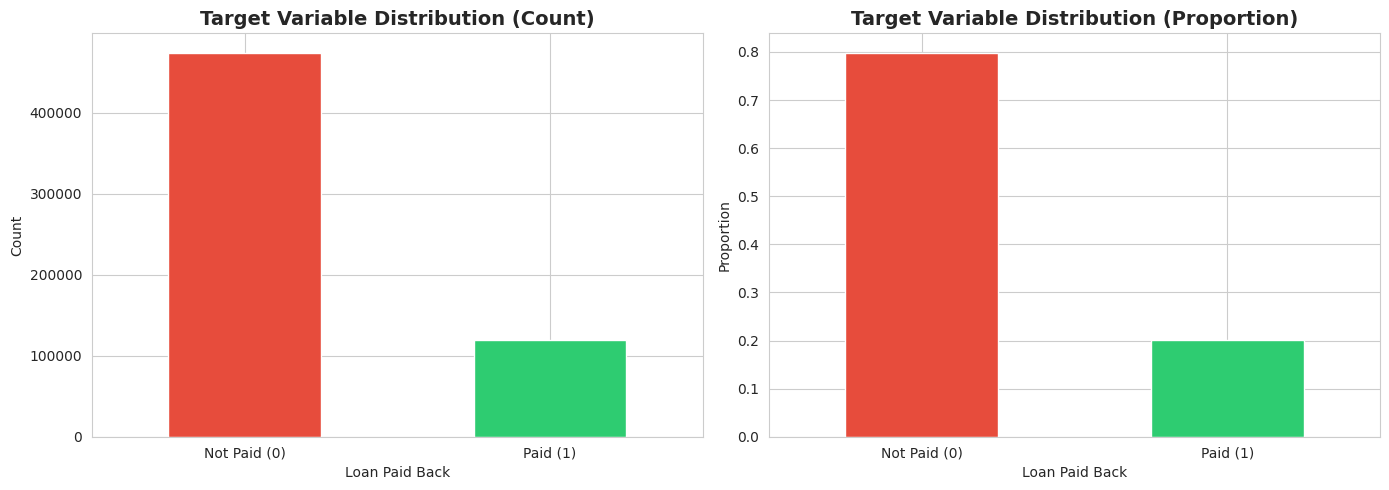


5. UNIVARIATE ANALYSIS - NUMERICAL FEATURES


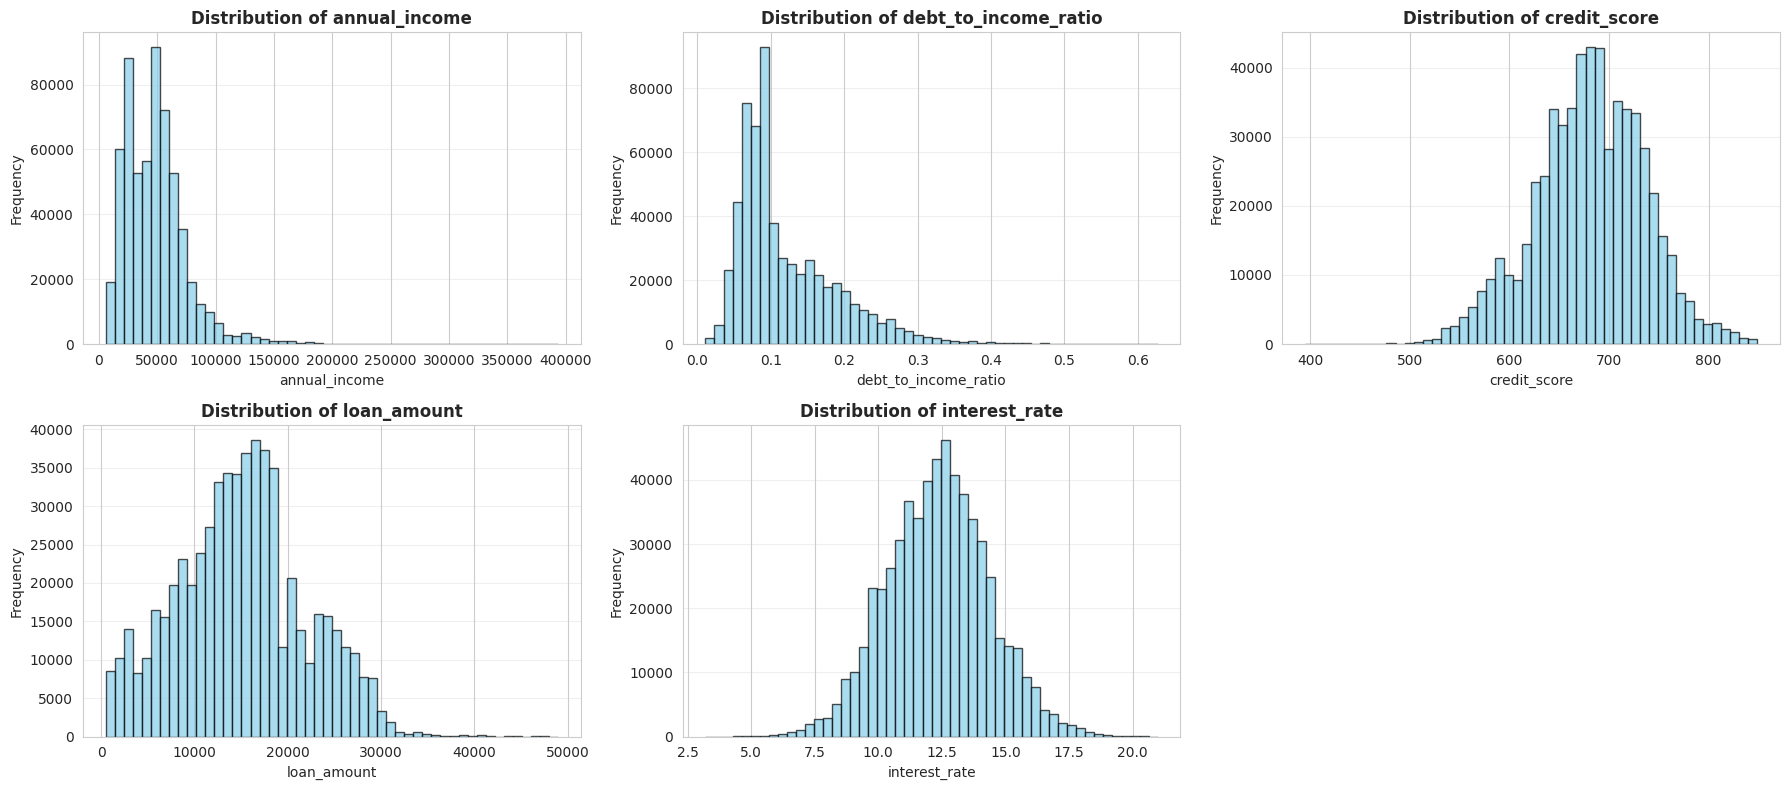

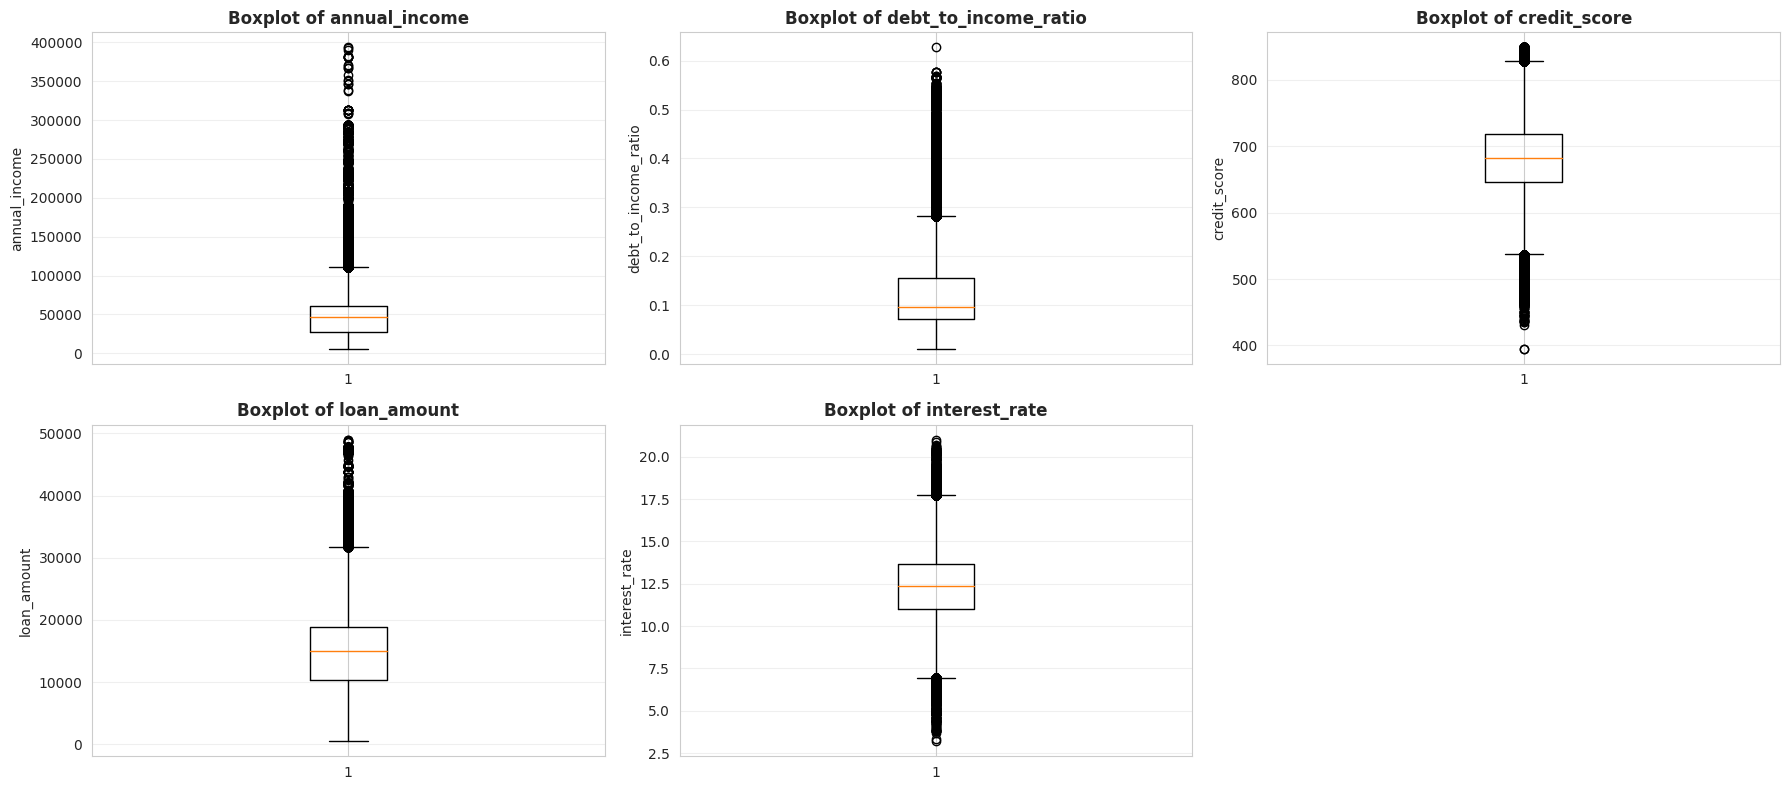


--- Skewness of Numerical Features ---
annual_income           1.719509
debt_to_income_ratio    1.406680
loan_amount             0.207360
interest_rate           0.049945
credit_score           -0.166993
dtype: float64

6. UNIVARIATE ANALYSIS - CATEGORICAL FEATURES


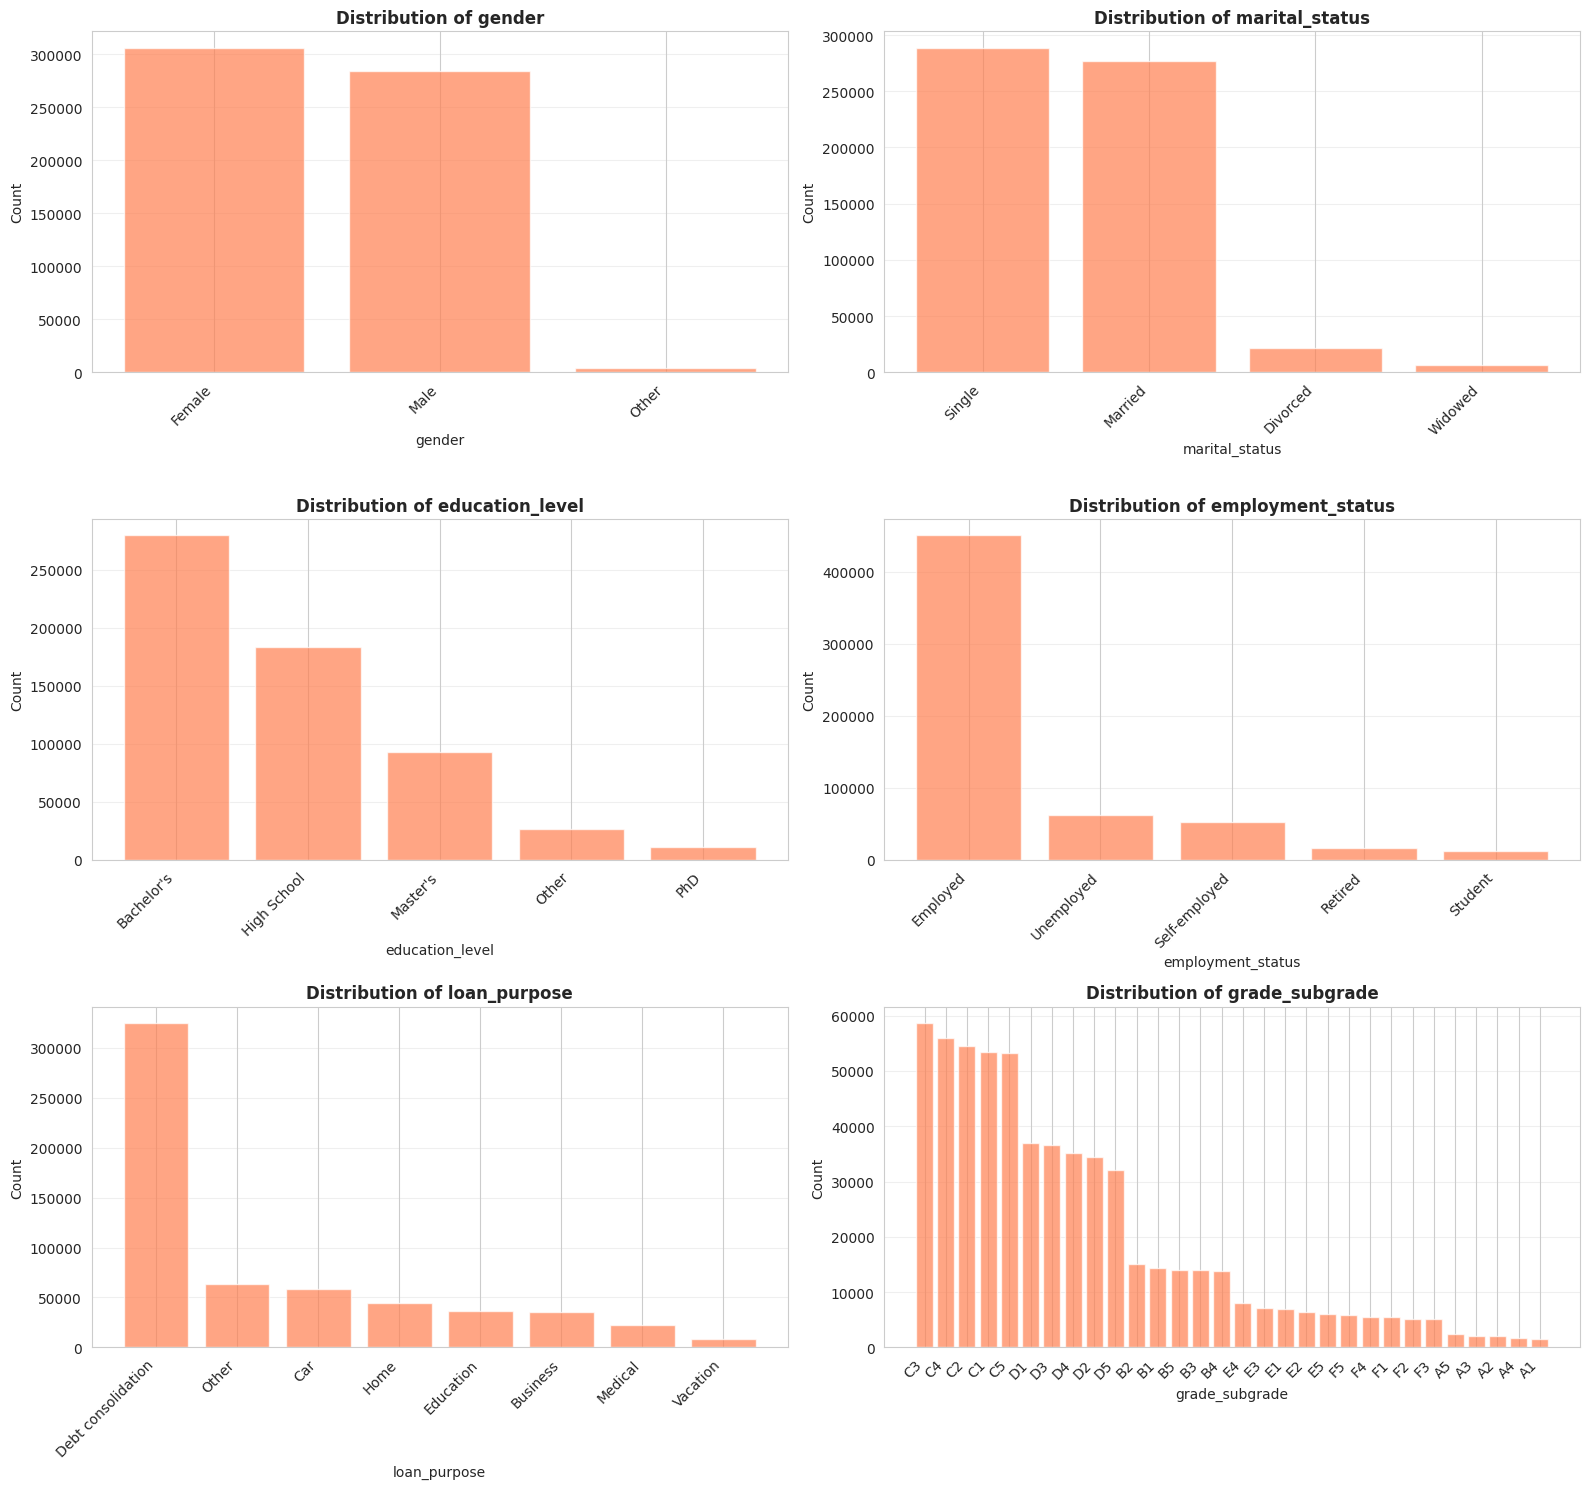


7. BIVARIATE ANALYSIS - TARGET vs FEATURES

--- Numerical Features vs Target ---


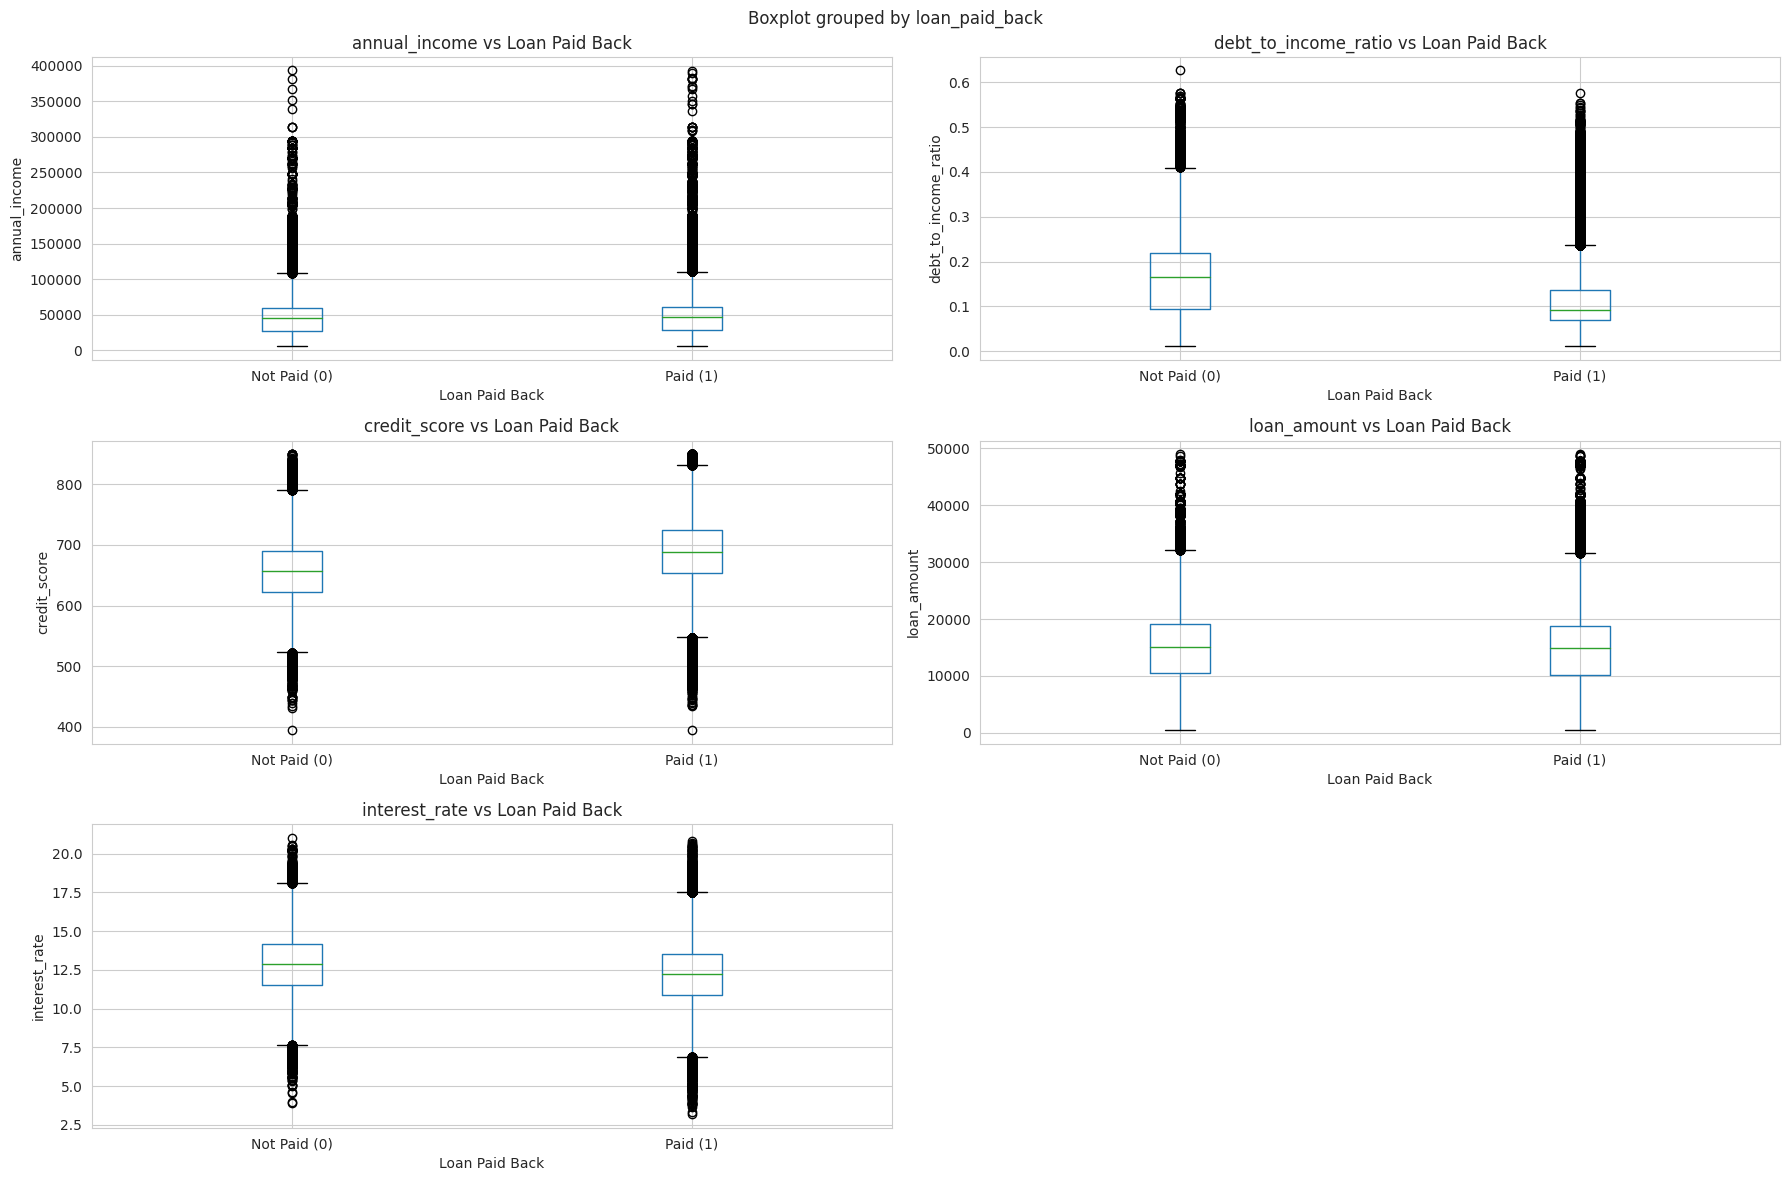


--- Categorical Features vs Target ---


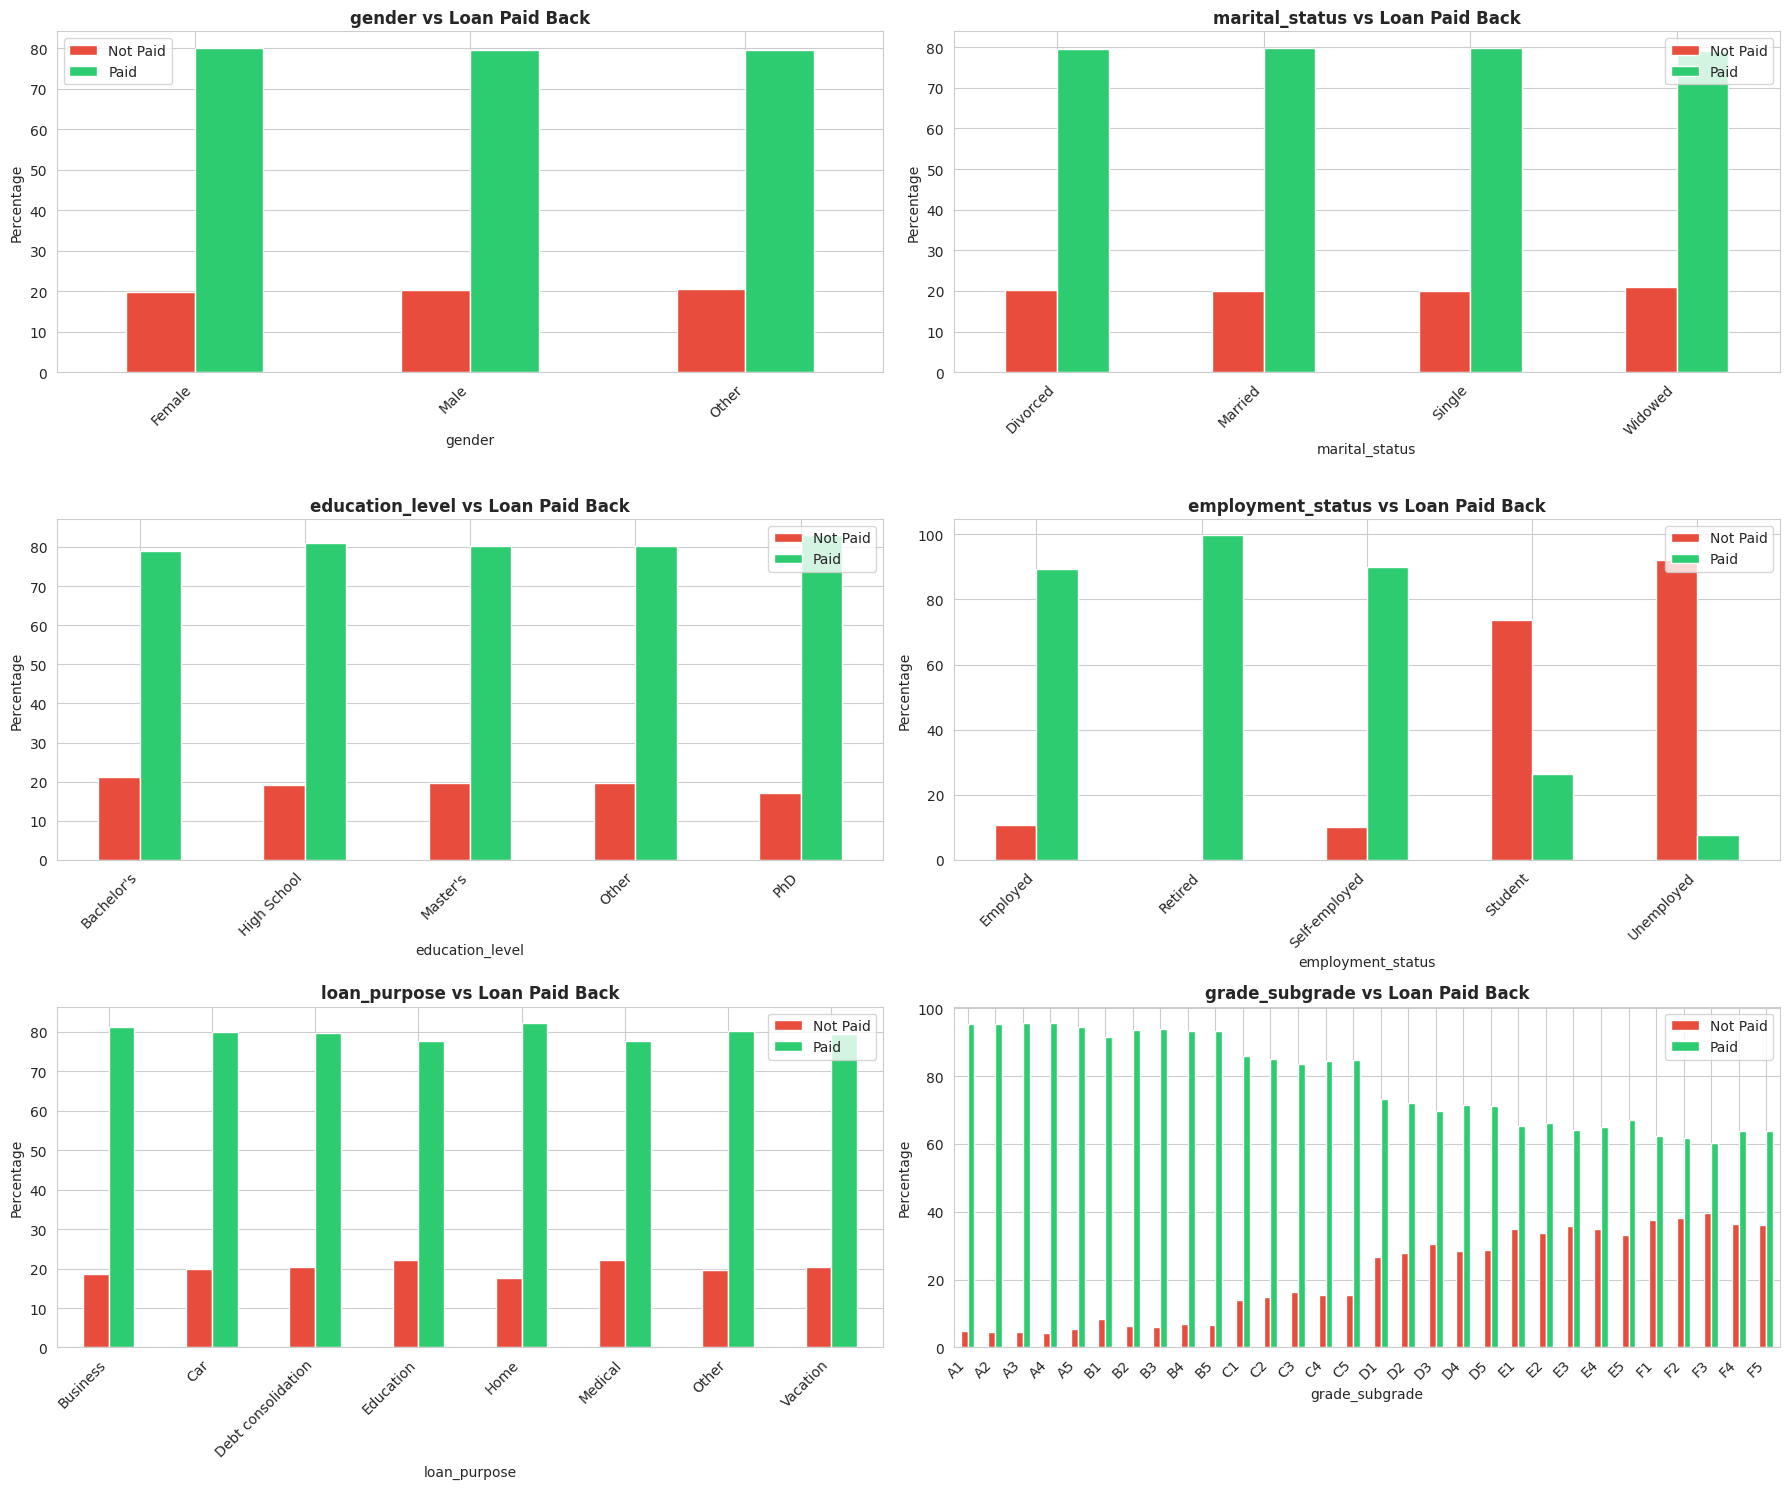


8. CORRELATION ANALYSIS

--- Correlation Matrix ---
                      annual_income  debt_to_income_ratio  credit_score  \
annual_income              1.000000              0.000553      0.001509   
debt_to_income_ratio       0.000553              1.000000     -0.061617   
credit_score               0.001509             -0.061617      1.000000   
loan_amount               -0.003407             -0.008236     -0.005761   
interest_rate             -0.002507              0.030316     -0.538335   
loan_paid_back             0.006326             -0.335680      0.234560   

                      loan_amount  interest_rate  loan_paid_back  
annual_income           -0.003407      -0.002507        0.006326  
debt_to_income_ratio    -0.008236       0.030316       -0.335680  
credit_score            -0.005761      -0.538335        0.234560  
loan_amount              1.000000      -0.001174       -0.003762  
interest_rate           -0.001174       1.000000       -0.131184  
loan_paid_back     

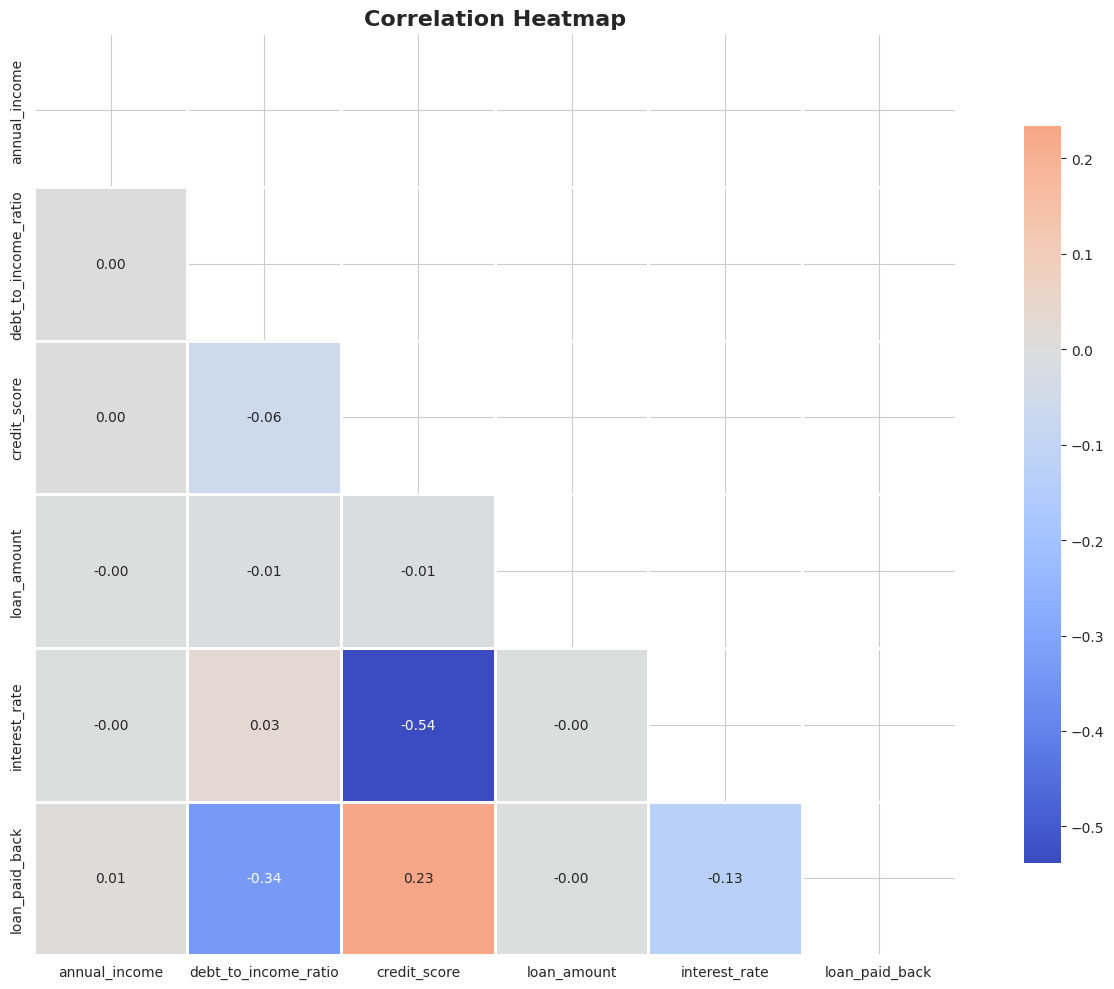


--- Top Correlations with Target Variable ---
credit_score            0.234560
annual_income           0.006326
loan_amount            -0.003762
interest_rate          -0.131184
debt_to_income_ratio   -0.335680
Name: loan_paid_back, dtype: float64


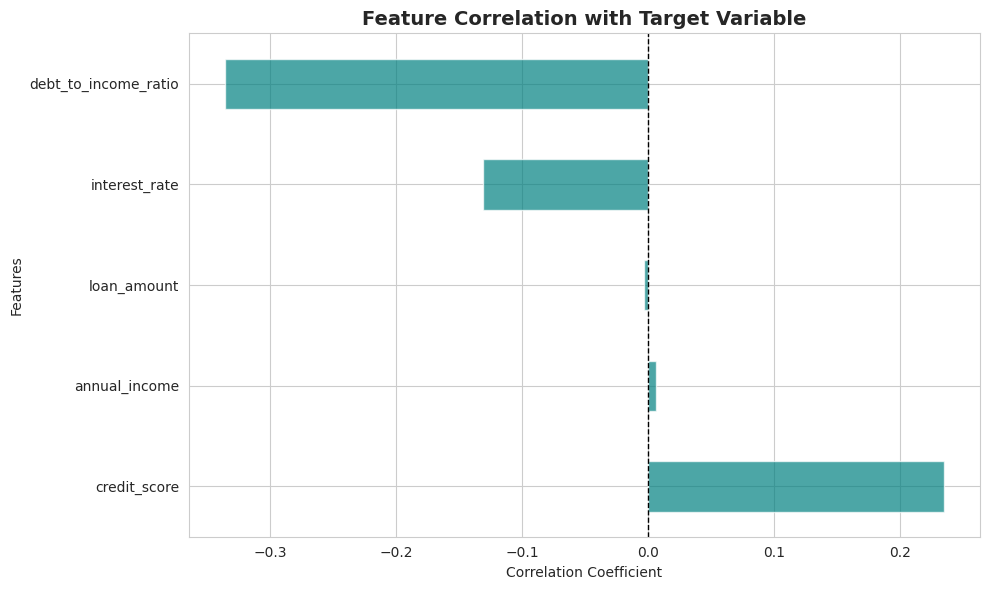


9. MULTIVARIATE ANALYSIS

--- Pairplot for Top 5 Features: ['credit_score', 'annual_income', 'loan_amount', 'interest_rate', 'debt_to_income_ratio'] ---


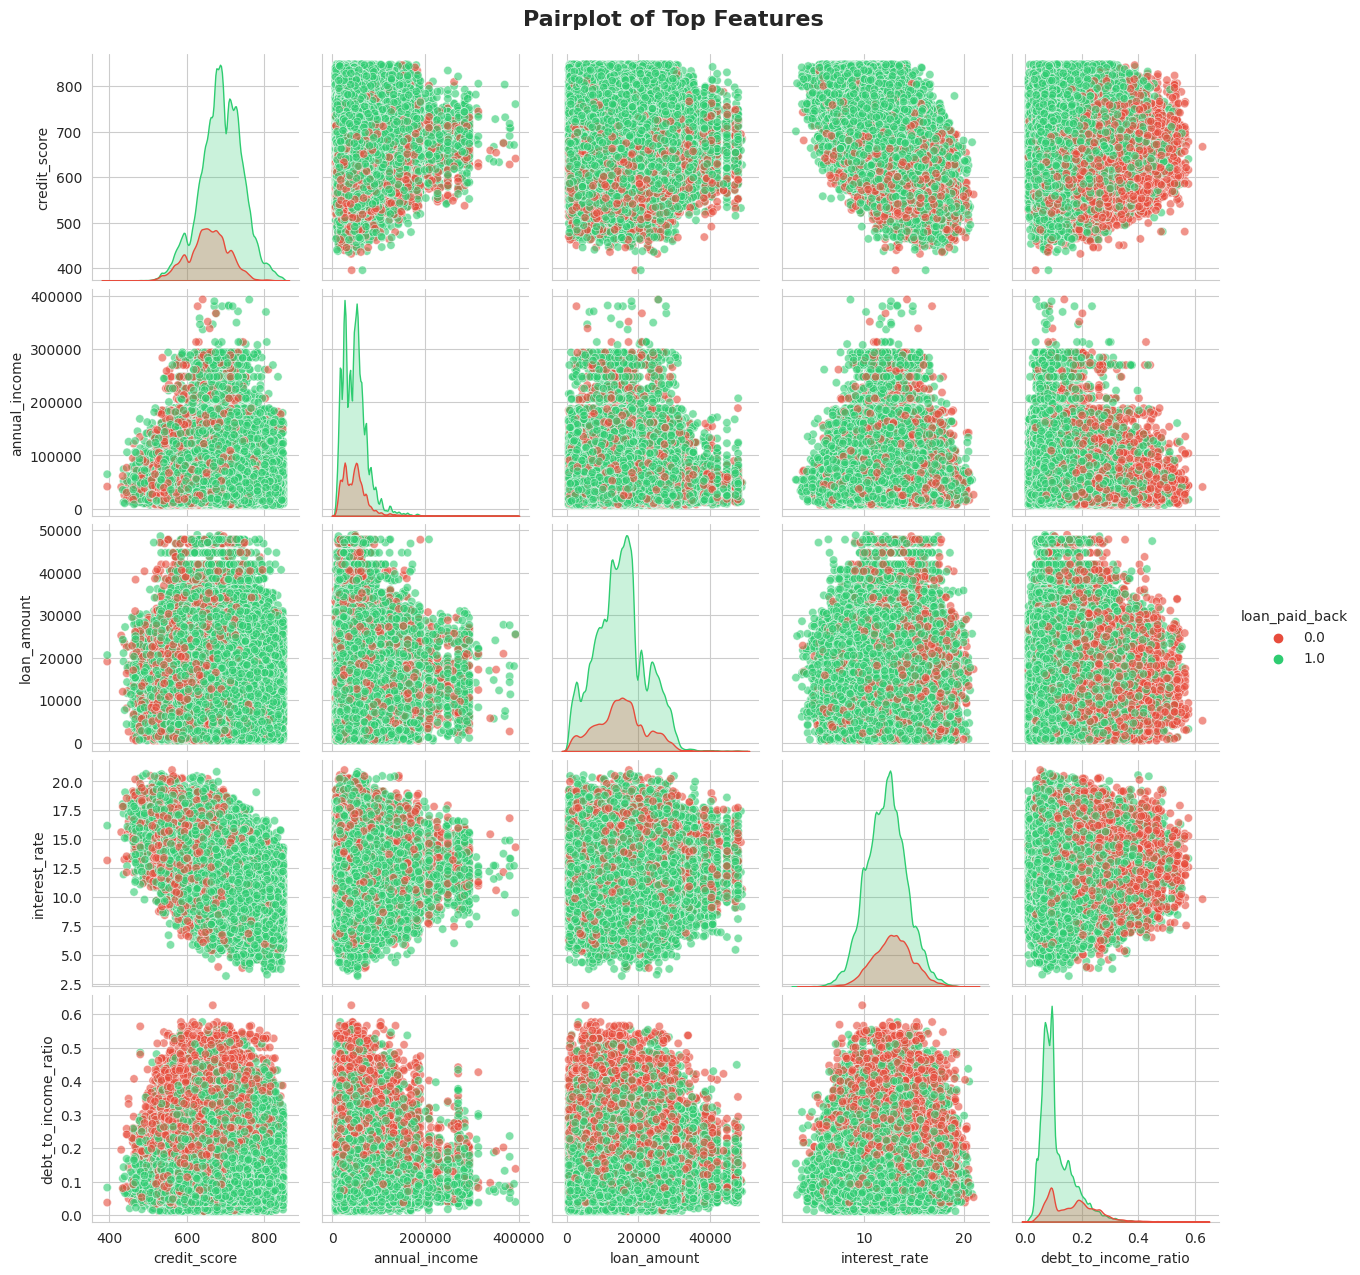


10. OUTLIER DETECTION (IQR Method)

--- Outlier Summary ---

annual_income:
  Outliers: 15917 (2.68%)
  Bounds: [-21635.98, 110551.70]

debt_to_income_ratio:
  Outliers: 17556 (2.96%)
  Bounds: [-0.05, 0.28]

credit_score:
  Outliers: 5901 (0.99%)
  Bounds: [536.50, 828.50]

loan_amount:
  Outliers: 2902 (0.49%)
  Bounds: [-2588.82, 31727.02]

interest_rate:
  Outliers: 5136 (0.86%)
  Bounds: [6.96, 17.71]

11. FEATURE ENGINEERING IDEAS

Based on the dataset, here are some feature engineering ideas:

1. Debt-to-Income Ratio: Already present as 'debt_to_income_ratio'
2. Loan-to-Income Ratio: loan_amount / annual_income
3. Credit Score Bins: Categorize credit scores (Poor, Fair, Good, Excellent)
4. Interest Rate Categories: Low, Medium, High interest rates
5. Age-derived features (if DOB available): Age, age groups
6. Income Categories: Low, Medium, High income brackets
7. Interaction Terms: credit_score * annual_income, etc.
8. Polynomial Features: For important numerical features
9. R

In [1]:
# Comprehensive Exploratory Data Analysis - Loan Dataset using ai
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Assuming train and test are already loaded
# If not, uncomment and modify:
train = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e11/test.csv")

print("="*80)
print("LOAN DATASET - COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)

# ========================================================
# 1. DATASET OVERVIEW
# ========================================================
print("\n" + "="*80)
print("1. DATASET OVERVIEW")
print("="*80)

print(f"\nTrain Dataset Shape: {train.shape}")
print(f"Test Dataset Shape: {test.shape}")

print("\n--- Train Dataset Info ---")
print(train.info())

print("\n--- Test Dataset Info ---")
print(test.info())

print("\n--- First few rows of Train ---")
print(train.head())

print("\n--- First few rows of Test ---")
print(test.head())

# ========================================================
# 2. DATA QUALITY CHECK
# ========================================================
print("\n" + "="*80)
print("2. DATA QUALITY ASSESSMENT")
print("="*80)

# Missing values
print("\n--- Missing Values in Train ---")
missing_train = train.isnull().sum()
missing_pct_train = (missing_train / len(train)) * 100
missing_df_train = pd.DataFrame({
    'Missing_Count': missing_train,
    'Percentage': missing_pct_train
}).sort_values('Missing_Count', ascending=False)
print(missing_df_train[missing_df_train['Missing_Count'] > 0])

print("\n--- Missing Values in Test ---")
missing_test = test.isnull().sum()
missing_pct_test = (missing_test / len(test)) * 100
missing_df_test = pd.DataFrame({
    'Missing_Count': missing_test,
    'Percentage': missing_pct_test
}).sort_values('Missing_Count', ascending=False)
print(missing_df_test[missing_df_test['Missing_Count'] > 0])

# Duplicate rows
print(f"\nDuplicate rows in Train: {train.duplicated().sum()}")
print(f"Duplicate rows in Test: {test.duplicated().sum()}")

# Data types
print("\n--- Data Types in Train ---")
print(train.dtypes.value_counts())

# ========================================================
# 3. STATISTICAL SUMMARY
# ========================================================
print("\n" + "="*80)
print("3. STATISTICAL SUMMARY")
print("="*80)

print("\n--- Numerical Features Summary (Train) ---")
print(train.describe().T)

print("\n--- Categorical Features Summary (Train) ---")
categorical_cols = train.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(train[col].value_counts())

# ========================================================
# 4. TARGET VARIABLE ANALYSIS (if exists)
# ========================================================
print("\n" + "="*80)
print("4. TARGET VARIABLE ANALYSIS")
print("="*80)

if 'loan_paid_back' in train.columns:
    print("\n--- Target Variable Distribution ---")
    print(train['loan_paid_back'].value_counts())
    print("\n--- Target Variable Proportions ---")
    print(train['loan_paid_back'].value_counts(normalize=True))
    
    # Visualize target distribution
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    train['loan_paid_back'].value_counts().plot(kind='bar', ax=ax[0], color=['#e74c3c', '#2ecc71'])
    ax[0].set_title('Target Variable Distribution (Count)', fontsize=14, fontweight='bold')
    ax[0].set_xlabel('Loan Paid Back')
    ax[0].set_ylabel('Count')
    ax[0].set_xticklabels(['Not Paid (0)', 'Paid (1)'], rotation=0)
    
    train['loan_paid_back'].value_counts(normalize=True).plot(kind='bar', ax=ax[1], color=['#e74c3c', '#2ecc71'])
    ax[1].set_title('Target Variable Distribution (Proportion)', fontsize=14, fontweight='bold')
    ax[1].set_xlabel('Loan Paid Back')
    ax[1].set_ylabel('Proportion')
    ax[1].set_xticklabels(['Not Paid (0)', 'Paid (1)'], rotation=0)
    
    plt.tight_layout()
    plt.show()
else:
    print("\nTarget variable 'loan_paid_back' not found in train dataset.")

# ========================================================
# 5. UNIVARIATE ANALYSIS - NUMERICAL FEATURES
# ========================================================
print("\n" + "="*80)
print("5. UNIVARIATE ANALYSIS - NUMERICAL FEATURES")
print("="*80)

numerical_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if 'id' in numerical_cols:
    numerical_cols.remove('id')
if 'loan_paid_back' in numerical_cols:
    numerical_cols.remove('loan_paid_back')

# Distribution plots
n_cols = 3
n_rows = int(np.ceil(len(numerical_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(train[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Box plots for outlier detection
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten() if n_rows > 1 else [axes]

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].boxplot(train[col].dropna(), vert=True)
        axes[idx].set_title(f'Boxplot of {col}', fontweight='bold')
        axes[idx].set_ylabel(col)
        axes[idx].grid(axis='y', alpha=0.3)

# Hide extra subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Skewness analysis
print("\n--- Skewness of Numerical Features ---")
skewness = train[numerical_cols].skew().sort_values(ascending=False)
print(skewness)

# ========================================================
# 6. UNIVARIATE ANALYSIS - CATEGORICAL FEATURES
# ========================================================
print("\n" + "="*80)
print("6. UNIVARIATE ANALYSIS - CATEGORICAL FEATURES")
print("="*80)

categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0:
    n_cols = 2
    n_rows = int(np.ceil(len(categorical_cols) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        if idx < len(axes):
            value_counts = train[col].value_counts()
            axes[idx].bar(range(len(value_counts)), value_counts.values, color='coral', alpha=0.7)
            axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Count')
            axes[idx].set_xticks(range(len(value_counts)))
            axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[idx].grid(axis='y', alpha=0.3)
    
    # Hide extra subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

# ========================================================
# 7. BIVARIATE ANALYSIS - TARGET vs FEATURES
# ========================================================
print("\n" + "="*80)
print("7. BIVARIATE ANALYSIS - TARGET vs FEATURES")
print("="*80)

if 'loan_paid_back' in train.columns:
    # Numerical features vs Target
    print("\n--- Numerical Features vs Target ---")
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten() if n_rows > 1 else [axes]
    
    for idx, col in enumerate(numerical_cols):
        if idx < len(axes):
            train.boxplot(column=col, by='loan_paid_back', ax=axes[idx])
            axes[idx].set_title(f'{col} vs Loan Paid Back')
            axes[idx].set_xlabel('Loan Paid Back')
            axes[idx].set_ylabel(col)
            plt.sca(axes[idx])
            plt.xticks([1, 2], ['Not Paid (0)', 'Paid (1)'])
    
    # Hide extra subplots
    for idx in range(len(numerical_cols), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Categorical features vs Target
    if len(categorical_cols) > 0:
        print("\n--- Categorical Features vs Target ---")
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 5))
        axes = axes.flatten() if n_rows > 1 else [axes]
        
        for idx, col in enumerate(categorical_cols):
            if idx < len(axes):
                ct = pd.crosstab(train[col], train['loan_paid_back'], normalize='index') * 100
                ct.plot(kind='bar', stacked=False, ax=axes[idx], color=['#e74c3c', '#2ecc71'])
                axes[idx].set_title(f'{col} vs Loan Paid Back', fontweight='bold')
                axes[idx].set_xlabel(col)
                axes[idx].set_ylabel('Percentage')
                axes[idx].legend(['Not Paid', 'Paid'])
                axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45, ha='right')
        
        # Hide extra subplots
        for idx in range(len(categorical_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.show()

# ========================================================
# 8. CORRELATION ANALYSIS
# ========================================================
print("\n" + "="*80)
print("8. CORRELATION ANALYSIS")
print("="*80)

# Correlation matrix
corr_matrix = train[numerical_cols + (['loan_paid_back'] if 'loan_paid_back' in train.columns else [])].corr()

print("\n--- Correlation Matrix ---")
print(corr_matrix)

# Heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target (if exists)
if 'loan_paid_back' in train.columns:
    print("\n--- Top Correlations with Target Variable ---")
    target_corr = corr_matrix['loan_paid_back'].drop('loan_paid_back').sort_values(ascending=False)
    print(target_corr)
    
    # Visualize
    plt.figure(figsize=(10, 6))
    target_corr.plot(kind='barh', color='teal', alpha=0.7)
    plt.title('Feature Correlation with Target Variable', fontsize=14, fontweight='bold')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()

# ========================================================
# 9. MULTIVARIATE ANALYSIS
# ========================================================
print("\n" + "="*80)
print("9. MULTIVARIATE ANALYSIS")
print("="*80)

# Pairplot for key numerical features (select top 5 by correlation with target)
if 'loan_paid_back' in train.columns and len(numerical_cols) > 0:
    top_features = target_corr.abs().head(5).index.tolist()
    
    print(f"\n--- Pairplot for Top 5 Features: {top_features} ---")
    
    if len(top_features) > 0:
        sns.pairplot(train[top_features + ['loan_paid_back']], 
                     hue='loan_paid_back', 
                     palette={0.0: '#e74c3c', 1.0: '#2ecc71'},
                     diag_kind='kde',
                     plot_kws={'alpha': 0.6})
        plt.suptitle('Pairplot of Top Features', y=1.02, fontsize=16, fontweight='bold')
        plt.show()

# ========================================================
# 10. OUTLIER DETECTION
# ========================================================
print("\n" + "="*80)
print("10. OUTLIER DETECTION (IQR Method)")
print("="*80)

def detect_outliers_iqr(df, columns):
    outlier_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_info[col] = {
            'count': len(outliers),
            'percentage': (len(outliers) / len(df)) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
    return outlier_info

outlier_info = detect_outliers_iqr(train, numerical_cols)

print("\n--- Outlier Summary ---")
for col, info in outlier_info.items():
    print(f"\n{col}:")
    print(f"  Outliers: {info['count']} ({info['percentage']:.2f}%)")
    print(f"  Bounds: [{info['lower_bound']:.2f}, {info['upper_bound']:.2f}]")

# ========================================================
# 11. FEATURE ENGINEERING IDEAS
# ========================================================
print("\n" + "="*80)
print("11. FEATURE ENGINEERING IDEAS")
print("="*80)

ideas = """
Based on the dataset, here are some feature engineering ideas:

1. Debt-to-Income Ratio: Already present as 'debt_to_income_ratio'
2. Loan-to-Income Ratio: loan_amount / annual_income
3. Credit Score Bins: Categorize credit scores (Poor, Fair, Good, Excellent)
4. Interest Rate Categories: Low, Medium, High interest rates
5. Age-derived features (if DOB available): Age, age groups
6. Income Categories: Low, Medium, High income brackets
7. Interaction Terms: credit_score * annual_income, etc.
8. Polynomial Features: For important numerical features
9. Risk Score: Composite score based on multiple factors
10. Education-Employment Interaction: Combined categorical feature
"""

print(ideas)

# ========================================================
# 12. KEY INSIGHTS & RECOMMENDATIONS
# ========================================================
print("\n" + "="*80)
print("12. KEY INSIGHTS & RECOMMENDATIONS")
print("="*80)

insights = """
Key Insights to Document:
1. Dataset balance/imbalance in target variable
2. Features with strong correlation to target
3. Presence of outliers and their impact
4. Missing value patterns
5. Categorical feature distributions
6. Feature importance based on correlation
7. Potential multicollinearity issues
8. Data quality concerns

Next Steps:
1. Handle missing values (imputation/removal)
2. Address outliers (cap/remove/transform)
3. Encode categorical variables
4. Scale/normalize numerical features
5. Feature selection based on correlation/importance
6. Create new features (feature engineering)
7. Handle class imbalance if present
8. Train baseline models and iterate
"""

print(insights)

print("\n" + "="*80)
print("EDA COMPLETE!")
print("="*80)

In [2]:
# ============================================================
#  Kaggle Playground Series S5E11 - Loan Repayment Prediction
#  Improved LightGBM Model + Feature Engineering
#  Compatible with LightGBM >= 4.0 (uses callbacks)
# ============================================================

!pip install -q lightgbm category_encoders

import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
from category_encoders.target_encoder import TargetEncoder
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation

# -----------------------------
# Load Data
# -----------------------------
train = pd.read_csv("/kaggle/input/playground-series-s5e11/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s5e11/test.csv")


id_col = "id"
target_col = "loan_paid_back"

X = train.drop(columns=[id_col, target_col])
y = train[target_col]
X_test = test.drop(columns=[id_col], errors='ignore')

# -----------------------------
# Feature Engineering
# -----------------------------

# 1️ Parse grade_subgrade into grade + subgrade
X["grade"] = X["grade_subgrade"].str.extract(r'([A-G])')
X["subgrade"] = X["grade_subgrade"].str.extract(r'(\d+)').astype(float)

X_test["grade"] = X_test["grade_subgrade"].str.extract(r'([A-G])')
X_test["subgrade"] = X_test["grade_subgrade"].str.extract(r'(\d+)').astype(float)

# Encode grade as numeric (A=1, B=2, etc.)
grade_map = {g: i for i, g in enumerate(sorted(X["grade"].dropna().unique()), 1)}
X["grade"] = X["grade"].map(grade_map)
X_test["grade"] = X_test["grade"].map(grade_map)

# 2️ Log-transform skewed numeric features
for col in ["annual_income", "loan_amount", "debt_to_income_ratio"]:
    if col in X.columns:
        X[col] = np.log1p(X[col])
        X_test[col] = np.log1p(X_test[col])

# 3️ Create ratio / interaction features
X["loan_to_income"] = X["loan_amount"] / (X["annual_income"] + 1)
X["income_to_debt_ratio"] = X["annual_income"] / (X["debt_to_income_ratio"] + 1)

X_test["loan_to_income"] = X_test["loan_amount"] / (X_test["annual_income"] + 1)
X_test["income_to_debt_ratio"] = X_test["annual_income"] / (X_test["debt_to_income_ratio"] + 1)

# 4 Target Encoding for categorical columns
cat_cols = ["loan_purpose", "employment_status", "education_level", "marital_status", "gender"]
encoder = TargetEncoder(cols=cat_cols, smoothing=0.3)
X[cat_cols] = encoder.fit_transform(X[cat_cols], y)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# Drop original composite column
X = X.drop(columns=["grade_subgrade"])
X_test = X_test.drop(columns=["grade_subgrade"])

# -----------------------------
# LightGBM Training (5-Fold CV)
# -----------------------------

params = {
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "learning_rate": 0.03,
    "num_leaves": 63,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 5,
    "lambda_l2": 0.2,
    "verbosity": -1,
    "seed": 42
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(X_test.shape[0])
oof = np.zeros(X.shape[0])

for fold, (tr_idx, val_idx) in enumerate(kf.split(X, y)):
    print(f"\n===== Fold {fold+1} =====")
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    dtr = lgb.Dataset(X_tr, label=y_tr)
    dval = lgb.Dataset(X_val, label=y_val)

    model = lgb.train(
        params,
        dtr,
        valid_sets=[dval],
        num_boost_round=2000,
        callbacks=[
            early_stopping(stopping_rounds=100),
            log_evaluation(200)
        ]
    )
    
    oof[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)
    test_preds += model.predict(X_test, num_iteration=model.best_iteration) / kf.n_splits

# Evaluate Out-of-Fold (OOF) AUC
auc_score = roc_auc_score(y, oof)
print(f"\n✅ CV AUC Score: {auc_score:.5f}")

# -----------------------------
# Save Submission File
# -----------------------------
submission = pd.DataFrame({
    id_col: test[id_col],
    target_col: test_preds
})
submission.to_csv("submission_improved.csv", index=False)
print("\n✅ submission_improved.csv saved successfully!")



===== Fold 1 =====
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.920879
[400]	valid_0's auc: 0.922146
[600]	valid_0's auc: 0.922658
[800]	valid_0's auc: 0.922753
[1000]	valid_0's auc: 0.922957
[1200]	valid_0's auc: 0.923042
Early stopping, best iteration is:
[1173]	valid_0's auc: 0.923046

===== Fold 2 =====
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.920636
[400]	valid_0's auc: 0.922012
[600]	valid_0's auc: 0.922448
[800]	valid_0's auc: 0.922638
[1000]	valid_0's auc: 0.922752
[1200]	valid_0's auc: 0.922885
[1400]	valid_0's auc: 0.922966
[1600]	valid_0's auc: 0.922951
Early stopping, best iteration is:
[1571]	valid_0's auc: 0.922988

===== Fold 3 =====
Training until validation scores don't improve for 100 rounds
[200]	valid_0's auc: 0.920888
[400]	valid_0's auc: 0.922133
[600]	valid_0's auc: 0.922553
[800]	valid_0's auc: 0.922627
Early stopping, best iteration is:
[704]	valid_0's auc: 0.922702

===== Fold